# Task 1 — Dataset Selection and Relevance: Household Electric Power Consumption

**Author:** Deepakkumar Govindan (s225234246) — Models sub-team

This notebook will continue into the Task 2 full data-quality analysis. This section covers Task 1's dataset selection and relevance justification.


## Dataset Selection and Relevance

### Dataset name and source
**Individual Household Electric Power Consumption**, from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption) 

### Domain / topic
Residential energy / smart-meter monitoring, which is a different application but a viable multi-sensor IoT time series compared to the other data sets that the other team members are looking at, that of seismic, wearable, and farming, etc.


### Why it was selected
- Real data, not synthetic or lab-simulated, from one household in Sceaux, France, minute-by-minute from December 2006 to November 2010 (approx. 4 years, 2,075,259 readings).
- It also bears real undocumented data quality issues — missing readings and multi-day outages of the kind we need to demonstrate our pipeline is robust in when it fails within NAB's purer benchmark data.
- It provides multiple correlated numeric channels from the same meter (see below), providing us with a true test of AIntl's cross-variable correlation logic, not just anomaly detection on a single series.
- It is well documented, readily available and of significant size yet yet still useable locally.

### Main variables available
| Variable | Description |
|---|---|
| `datetime` | Minute-level timestamp |
| `Global_active_power` | Total real power consumed (kW) |
| `Global_reactive_power` | Total reactive power (kVAR) |
| `Voltage` | Mains voltage (V) |
| `Global_intensity` | Total current intensity (A) |
| `Sub_metering_1` | Kitchen circuit (Wh) |
| `Sub_metering_2` | Laundry room circuit (Wh) |
| `Sub_metering_3` | Water-heater / air-conditioner circuit (Wh) |

**Timestamps:** Yes, there is a timestamps index with a minute-level `datetime` index that goes over ~4 years.

**Numeric variables suitable for anomaly analysis:** Yes — all seven measurement columns are above are Continuous Numeric readings suitable for point & sequence-level anomaly detection (spikes, gaps, drift).


**Two or more variables useful for correlation:** yes, Global_active_power should track closely with the sum of some three sub-metering channels and Global_intensity, under normal conditions, and Voltage should be relatively constant, regardless of load. This provides AIntl with real relationships to test, for example, if the total power increases and then drops abnormally, does the current draw drop or does the sub-meter reading drop?

### Suitability for the IoT Analytics MVP
Suitable. It is a real multi-channel, timestamped stream from a single real world device, structurally the same as the Models/AIntl pipeline was designed to consume (timestamp + numeric sensor reading) and it is big enough and dirty enough that it's a meaningful and realistic test of the pipeline outside of the context of the NAB dataset.

### Expected anomaly / unusual-behaviour types
- Missing-data gaps: Minutes and full-day outages that are missing due to a real device going offline, which should be detected by the input validator's missing-value checks and by the missing-data logic in LevelShiftAD.
- Point anomalies / spikes — unusually high power draw (e.g. evening heating load), can be tested using QuantileAD, ECOD, COPOD, Isolation Forest.
A scenario where `Global_active_power` and `Global_intensity` no longer match, or where the sum of sub-metering channels is significantly different from the global reading, which may be suggested by AIntl's correlation-based detection.


---
## Preliminary Exploration

Light exploration only confirms the dataset is accessible locally and has the expected shape. Full data-quality analysis belongs in Task 2.


In [1]:
import pandas as pd

hourly = pd.read_csv("data/household_power_hourly.csv", parse_dates=["datetime"], index_col="datetime")
daily_missing = pd.read_csv("data/household_power_daily_missing.csv", parse_dates=["datetime"], index_col="datetime")

print(hourly.shape, daily_missing.shape)
hourly.head()

(34589, 7) (1442, 1)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [2]:
hourly.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000
mean,1.091728,0.123727,240.839393,4.628238,1.121631,1.298566,6.458882
std,0.897619,0.066851,3.001093,3.757797,3.538046,4.192874,7.351219
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341925,0.078000,239.180667,1.513333,0.000000,0.000000,0.650000
50%,0.802850,0.106917,240.977833,3.423333,0.000000,0.333333,1.650000
75%,1.579342,0.149433,242.695000,6.606667,0.000000,0.650000,14.216667
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


### Quick look: missing-data gaps

In [3]:
worst_days = daily_missing.sort_values("missing_minutes", ascending=False).head(10)
worst_days

,missing_minutes
datetime,
2010-09-27,1440
2007-04-29,1440
2010-09-26,1440
2010-08-21,1440
2010-08-20,1440
2010-08-19,1440
2009-06-14,1440
2010-08-18,1440
2010-01-13,1440


### Quick look: consumption spikes

In [4]:
q999 = hourly['Global_active_power'].quantile(0.999)
spikes = hourly[hourly['Global_active_power'] > q999].sort_values('Global_active_power', ascending=False)
print(f"99.9th percentile hourly draw: {q999:.2f} kW")
print(f"Number of hours above it: {len(spikes)}")
spikes[['Global_active_power']].head(10)

99.9th percentile hourly draw: 5.17 kW
Number of hours above it: 35


,Global_active_power
datetime,
2008-11-23 18:00:00,6.560533
2009-01-16 20:00:00,6.519633
2008-02-02 19:00:00,6.496033
2007-12-23 19:00:00,6.488000
2007-02-22 21:00:00,6.363867
2007-12-28 17:00:00,6.333667
2008-11-23 20:00:00,6.310567
2007-01-21 20:00:00,6.076567
2008-01-26 19:00:00,6.013800


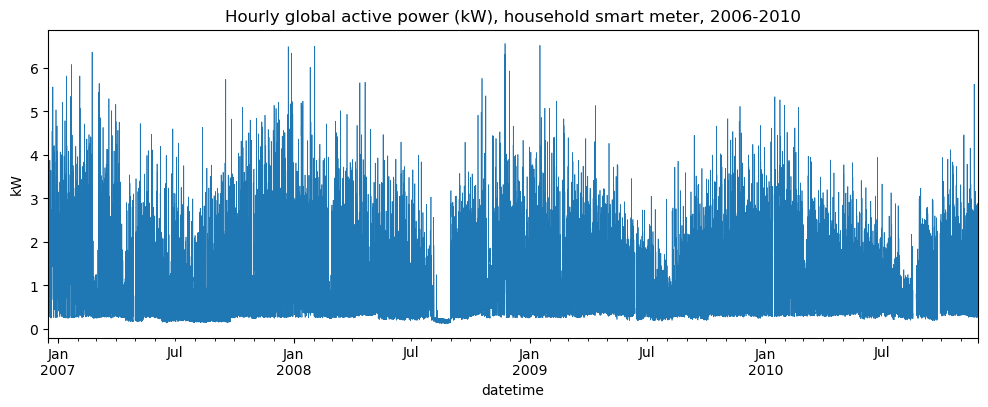

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
hourly['Global_active_power'].plot(ax=ax, linewidth=0.5)
ax.set_title("Hourly global active power (kW), household smart meter, 2006-2010")
ax.set_ylabel("kW")
plt.show()

### Quick look: correlation potential

In [6]:
hourly[['Global_active_power','Global_intensity','Voltage']].corr()

,Global_active_power,Global_intensity,Voltage
Global_active_power,1.000000,0.999423,-0.379450
Global_intensity,0.999423,1.000000,-0.392769
Voltage,-0.379450,-0.392769,1.000000


## Definition of Done — status

- [x] Dataset obtained and accessible locally (`data/household_power_hourly.csv`, `data/household_power_daily_missing.csv`)
- [x] Source/provenance recorded (UCI ML Repository, dataset 235)
- [x] Contains suitable time-series/numeric information (7 numeric channels, minute-level timestamps)
- [x] Relevance to anomaly detection, AIntl, and the MVP justified above
- [ ] Full data-quality analysis — **Task 2**


---
# Task 2 — Evaluating Models/AIntl on the Household Power Dataset




In [7]:
import sys, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# repo root is three levels up from data_science/datasets/household-power/
REPO_ROOT = Path.cwd().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from data_science.input_validator import validate_input, InputValidationError
from data_science.detector_runner import run_detector
from analytics_integration.pipeline import run_analytics_pipeline, run_correlation_path

print("Repo root:", REPO_ROOT)


Repo root: /Users/deepak/pradeep-fork


## Data Integrity / EDA

Starting from the raw hourly file produced in Task 1 and re-examine it properly before touching the pipeline.

In [8]:
raw = pd.read_csv("data/household_power_hourly.csv", parse_dates=["datetime"])
print("Shape:", raw.shape)
raw.dtypes

Shape: (34589, 8)


datetime                 datetime64[ns]
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
dtype: object

**Timestamp quality:** the `datetime` column is hourly, generated by resampling the original minute-level series in Task 1. Check it is unique, sorted, and evenly spaced.

In [9]:
ts = raw["datetime"]
print("Unique timestamps:", ts.is_unique)
print("Sorted ascending:", ts.is_monotonic_increasing)
gaps = ts.diff().dropna()
print("Gap sizes present:", gaps.value_counts().head())
print("All gaps exactly 1 hour (i.e. no skipped timestamps in the index itself)?", (gaps == pd.Timedelta(hours=1)).all())

Unique timestamps: True
Sorted ascending: True
Gap sizes present: datetime
0 days 01:00:00    34588
Name: count, dtype: int64
All gaps exactly 1 hour (i.e. no skipped timestamps in the index itself)? True


So the hourly index itself has no skipped timestamps — every hour in the range is represented as a row. The missingness lives *inside* the numeric columns instead (an hour exists as a row, but its readings are `NaN` if the smart meter reported nothing that hour).

In [10]:
missing = raw.isna().sum()
print("Missing values per column:")
print(missing)
print(f"\nRows with at least one missing value: {raw.isna().any(axis=1).sum()} / {len(raw)} ({raw.isna().any(axis=1).mean()*100:.2f}%)")
print(f"Duplicate rows: {raw.duplicated().sum()}")
print(f"Duplicate timestamps: {raw['datetime'].duplicated().sum()}")

Missing values per column:
datetime                   0
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

Rows with at least one missing value: 421 / 34589 (1.22%)
Duplicate rows: 0
Duplicate timestamps: 0


In [11]:
raw.describe()

,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000
mean,2008-12-06 07:00:00,1.091728,0.123727,240.839393,4.628238,1.121631,1.298566,6.458882
min,2006-12-16 17:00:00,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,2007-12-12 00:00:00,0.341925,0.078000,239.180667,1.513333,0.000000,0.000000,0.650000
50%,2008-12-06 07:00:00,0.802850,0.106917,240.977833,3.423333,0.000000,0.333333,1.650000
75%,2009-12-01 14:00:00,1.579342,0.149433,242.695000,6.606667,0.000000,0.650000,14.216667
max,2010-11-26 21:00:00,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000
std,NaN,0.897619,0.066851,3.001093,3.757797,3.538046,4.192874,7.351219


Distribution plots for both Value ranges / distributions are right-skewed with a long-tail of frequent high-usage hours, which is consistent with the typical "residential load" pattern of mostly low baseline draw, with occasional high-load moments. `Voltage` is tightly bounded (226-252 V) as expected of a mains supply. The 3 sub-metering channels have mostly zeros (appliance off that hour) and occasional non-zero bursts.

**Preprocessing necessary?** Yes — 421 of 34,589 hourly rows (1.2%) have missing readings and will need to be dealt with before the pipeline can take the data (confirmed in section 2.3 below).

**Variable choice:**
- Anomaly detection metric: Global_active_power — the one most representative of the overall load of the house, and the variable closest to a generic IoT "sensor value" stream.
The interesting case is the correlation of Global_active_power vs Voltage (approx -0.38) which is bigger and, as it depends on real load, varies from hour to hour; the near-perfectly coupled case by definition is the correlation of Global_active_power vs Global_intensity (approx 0.9994).

Assumptions: missing readings are removed from the rows, not imputed (imputation is not done in the current pipeline; see Limitations). The data from Task 1 were sampled every hour and are used as the working resolution throughout, rather than at the original minute level.

## Correlation Structure Across All Channels

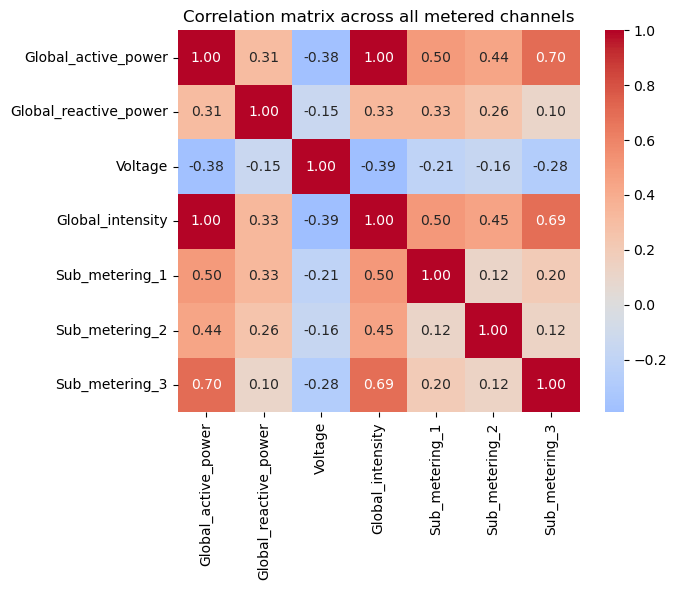

In [12]:
cols = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity","Sub_metering_1","Sub_metering_2","Sub_metering_3"]
corr_matrix = raw[cols].corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix across all metered channels")
fig.tight_layout()
plt.show()

## Preprocessing

Drop rows with any missing reading (documented, not silently imputed), and format the timestamp as the ISO-8601 string the pipeline expects.

In [13]:
before = len(raw)
clean = raw.dropna(subset=["Global_active_power", "Voltage", "Global_intensity"]).reset_index(drop=True)
after = len(clean)
print(f"Rows before: {before}, after dropping missing readings: {after}, dropped: {before-after} ({(before-after)/before*100:.2f}%)")

clean["timestamp"] = clean["datetime"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")
clean.head(2)

Rows before: 34589, after dropping missing readings: 34168, dropped: 421 (1.22%)


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,timestamp
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.1,0.0,0.527778,16.861111,2006-12-16T17:00:00Z
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.6,0.0,6.716667,16.866667,2006-12-16T18:00:00Z


## Evidence: the input validator correctly rejects unprocessed data

Before running the happy path, confirm the pipeline behaves safely on the *raw* (uncleaned) data — this is exactly the kind of evidence Sarah's review process asks for, not just a description of what the validator is supposed to do.

In [14]:
raw_for_pipeline = raw.copy()
raw_for_pipeline["timestamp"] = raw_for_pipeline["datetime"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")

try:
    run_analytics_pipeline(
        df=raw_for_pipeline,
        timestamp_col="timestamp",
        entity_id="household_power_meter",
        model_metric="Global_active_power",
        correlation_streams=["Global_active_power", "Voltage"],
        detector_name="isolationforest",
    )
    print("Did not raise -- unexpected")
except InputValidationError as e:
    print(f"Correctly rejected: {type(e).__name__}: {e}")

Correctly rejected: InputValidationError: Missing (NaN) values found in sensor columns: {'Global_active_power': 421}


##  Models Path — Isolation Forest on `Global_active_power`

`Dataset -> Models input validation -> Isolation Forest runtime -> Models adapter`

In [15]:
model_df = clean.set_index("datetime")[["Global_active_power"]]
validated = validate_input(model_df, min_readings=20)

result = run_detector("isolationforest", validated[["Global_active_power"]], parameters={"contamination": 0.01})
flag = result["anomaly_flag"]
score = result["score"]

print("Status:", "success" if flag is not None else "failed")
print(f"Flagged anomalies: {flag.sum()} / {len(flag)} ({flag.mean()*100:.2f}%)")
print(f"Models runtime: {result['runtime']:.4f}s")

Status: success
Flagged anomalies: 336 / 34168 (0.98%)
Models runtime: 0.2234s


In [16]:
flagged = validated[flag].copy()
flagged["score"] = score[flag]
flagged.sort_values("score", ascending=False).head(10)

,Global_active_power,score
datetime,,
2009-01-16 20:00:00,6.519633,0.102088
2008-11-23 18:00:00,6.560533,0.102088
2008-01-26 19:00:00,6.013800,0.100995
2008-11-23 20:00:00,6.310567,0.100995
2007-12-23 19:00:00,6.488000,0.100995
2007-01-21 20:00:00,6.076567,0.100995
2007-12-28 17:00:00,6.333667,0.100995
2007-02-22 21:00:00,6.363867,0.100995
2008-02-02 19:00:00,6.496033,0.100995


### Cross-check against domain knowledge

This dataset does not have a labeled ground truth, so precision/recall cannot be computed. Let's see if the detector's flags are correlated with independently identified statistical outliers—the top 0.1th percentile spike hours determined during Task 1's exploration—is a sanity check to see if the detector is seeing something real.

In [17]:
q999 = validated["Global_active_power"].quantile(0.999)
known_spikes = set(validated[validated["Global_active_power"] > q999].index)
flagged_idx = set(validated.index[flag])
overlap = known_spikes & flagged_idx

print(f"Known top-0.1%-percentile spike hours: {len(known_spikes)}")
print(f"Overlap with IsolationForest-flagged anomalies: {len(overlap)} / {len(known_spikes)} ({len(overlap)/len(known_spikes)*100:.1f}%)")

low_vals = validated[validated["Global_active_power"] < 0.15]
print(f"\nRows with unusually LOW power (< 0.15 kW, likely vacation/away periods): {len(low_vals)}")
print(f"Of those, flagged as anomalies: {int(flag.reindex(low_vals.index).sum())}")

Known top-0.1%-percentile spike hours: 35
Overlap with IsolationForest-flagged anomalies: 35 / 35 (100.0%)

Rows with unusually LOW power (< 0.15 kW, likely vacation/away periods): 73
Of those, flagged as anomalies: 0


In [18]:
result2 = run_detector("isolationforest", validated[["Global_active_power"]], parameters={"contamination": 0.01})
same = (result["anomaly_flag"] == result2["anomaly_flag"]).all()
print(f"Deterministic across repeated runs (fixed random_state)? {same}")

Deterministic across repeated runs (fixed random_state)? True


## Visualisation: flagged anomalies over time

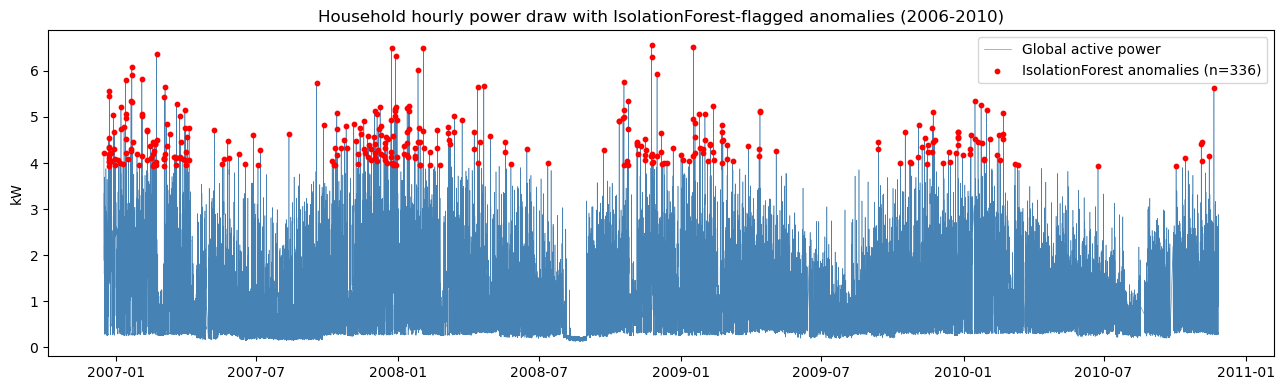

In [19]:
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(validated.index, validated["Global_active_power"], linewidth=0.4, color="steelblue", label="Global active power")
ax.scatter(validated.index[flag], validated["Global_active_power"][flag], color="red", s=10, zorder=5, label=f"IsolationForest anomalies (n={int(flag.sum())})")
ax.set_title("Household hourly power draw with IsolationForest-flagged anomalies (2006-2010)")
ax.set_ylabel("kW")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

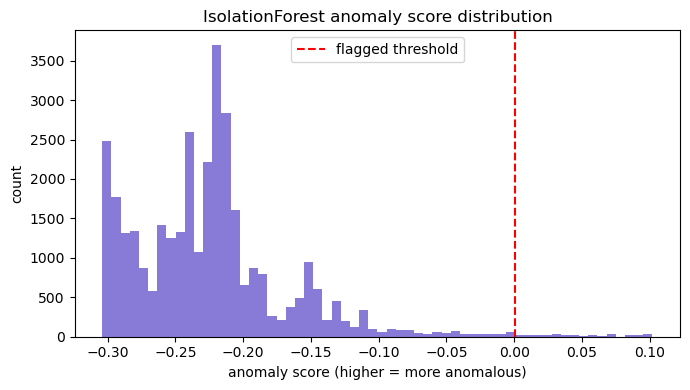

In [20]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(score, bins=60, color="slateblue", alpha=0.8)
ax.axvline(score[flag].min(), color="red", linestyle="--", label="flagged threshold")
ax.set_title("IsolationForest anomaly score distribution")
ax.set_xlabel("anomaly score (higher = more anomalous)")
ax.set_ylabel("count")
ax.legend()
fig.tight_layout()
plt.show()

## Correlation Path — two experiments

`Dataset -> Correlation Flask API -> Correlation adapter`

**Experiment A** — a physically near-identical pair (`Global_active_power` vs `Global_intensity`): should show a stable, near-1 correlation throughout, i.e. the detector should correctly stay quiet.

**Experiment B** — a genuinely fluctuating pair (`Global_active_power` vs `Voltage`): real load-driven voltage sag means their correlation should drift window to window, giving the detector something real to flag.

In [21]:
alerts_a, raw_a = run_correlation_path(
    df=clean, timestamp_col="timestamp",
    correlation_streams=["Global_active_power", "Global_intensity"],
    window_size=24, step_size=12, method="pearson",
)
print(f"Experiment A (active_power vs intensity): alerts = {len(alerts_a)}")

alerts_b, raw_b = run_correlation_path(
    df=clean, timestamp_col="timestamp",
    correlation_streams=["Global_active_power", "Voltage"],
    window_size=24, step_size=12, method="pearson",
)
print(f"Experiment B (active_power vs voltage): alerts = {len(alerts_b)}")

sev_counts = {}
for a in alerts_b:
    sev_counts[a["severity"]] = sev_counts.get(a["severity"], 0) + 1
print("Experiment B severity breakdown:", sev_counts)

2026-09-03T22:48:13 INFO    correlation.api          request_id=56676152 event=received source=json rows_in=34168 streams=Global_active_power,Global_intensity window_size=24 step_size=12 method=pearson
2026-09-03T22:48:13 INFO    correlation.api          request_id=56676152 event=completed rows_out=34168 windows=2846 alerts=0 runtime_ms=433
Experiment A (active_power vs intensity): alerts = 0
2026-09-03T22:48:14 INFO    correlation.api          request_id=5bc27377 event=received source=json rows_in=34168 streams=Global_active_power,Voltage window_size=24 step_size=12 method=pearson
2026-09-03T22:48:14 INFO    correlation.api          request_id=5bc27377 event=completed rows_out=34168 windows=2846 alerts=305 runtime_ms=379
Experiment B (active_power vs voltage): alerts = 305
Experiment B severity breakdown: {'MEDIUM': 88, 'LOW': 208, 'HIGH': 9}


Experiment B (active_power vs voltage): alerts = 305
Experiment B severity breakdown: {'MEDIUM': 88, 'LOW': 208, 'HIGH': 9}


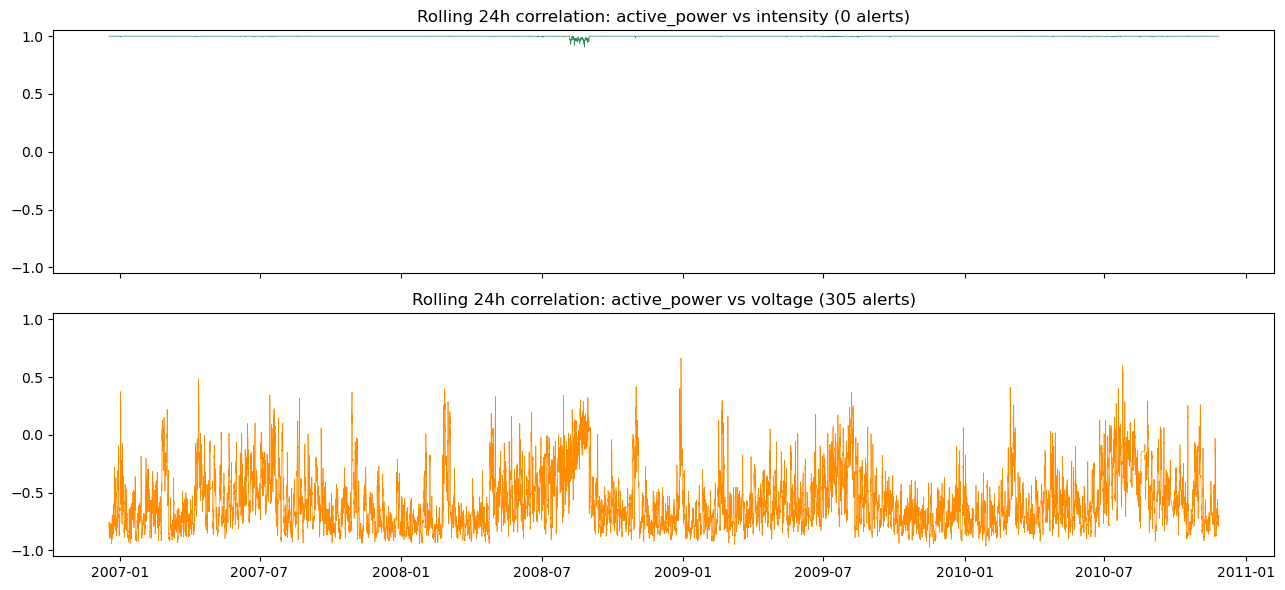

In [22]:
def rolling_corr(a, b, window=24):
    return a.rolling(window).corr(b)

roll_ai = rolling_corr(clean["Global_active_power"], clean["Global_intensity"])
roll_av = rolling_corr(clean["Global_active_power"], clean["Voltage"])

fig, axes = plt.subplots(2, 1, figsize=(13,6), sharex=True)
axes[0].plot(clean["datetime"], roll_ai, linewidth=0.5, color="seagreen")
axes[0].set_title(f"Rolling 24h correlation: active_power vs intensity ({len(alerts_a)} alerts)")
axes[0].set_ylim(-1.05, 1.05)
axes[1].plot(clean["datetime"], roll_av, linewidth=0.5, color="darkorange")
axes[1].set_title(f"Rolling 24h correlation: active_power vs voltage ({len(alerts_b)} alerts)")
axes[1].set_ylim(-1.05, 1.05)
fig.tight_layout()
plt.show()

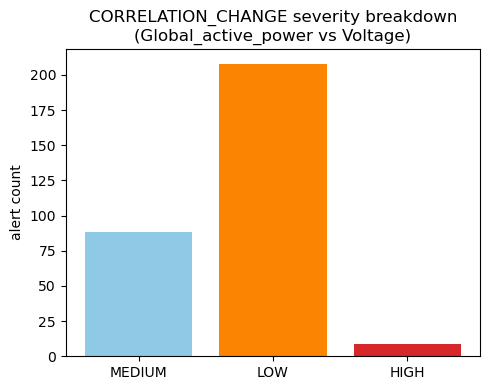

In [23]:
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(sev_counts.keys(), sev_counts.values(), color=["#8ecae6","#fb8500","#d62828"][:len(sev_counts)])
ax.set_title("CORRELATION_CHANGE severity breakdown\n(Global_active_power vs Voltage)")
ax.set_ylabel("alert count")
fig.tight_layout()
plt.show()

## Full AIntl Pipeline — Draft V0.1 Validated Response

`Dataset -> Models input validation -> Isolation Forest -> Models adapter -> Correlation path -> Correlation adapter -> Analytics response -> Draft V0.1 validation`

In [24]:
t0 = time.time()
response = run_analytics_pipeline(
    df=clean,
    timestamp_col="timestamp",
    entity_id="household_power_meter",
    model_metric="Global_active_power",
    correlation_streams=["Global_active_power", "Voltage"],
    detector_name="isolationforest",
    detector_parameters={"contamination": 0.01},
    correlation_window_size=24,
    correlation_step_size=12,
    correlation_method="pearson",
)
t1 = time.time()

alert_types = {}
for a in response["alerts"]:
    alert_types[a["alert_type"]] = alert_types.get(a["alert_type"], 0) + 1

print("Status:", response["status"])
print("Processed items:", response["summary"]["processed_items"])
print("Total alerts:", response["summary"]["alert_count"])
print("Alert type breakdown:", alert_types)
print("Errors:", response["errors"])
print(f"Wall time: {t1-t0:.2f}s")
print("\nFinal response passed Draft V0.1 validation (run_analytics_pipeline raises if it doesn't).")

2026-09-03T22:48:16 INFO    correlation.api          request_id=b67a45f9 event=received source=json rows_in=34168 streams=Global_active_power,Voltage window_size=24 step_size=12 method=pearson
2026-09-03T22:48:16 INFO    correlation.api          request_id=b67a45f9 event=completed rows_out=34168 windows=2846 alerts=305 runtime_ms=340
Status: success
Processed items: 34168
Total alerts: 641
Alert type breakdown: {'POINTWISE_ANOMALY': 336, 'CORRELATION_CHANGE': 305}
Errors: []
Wall time: 1.35s

Final response passed Draft V0.1 validation (run_analytics_pipeline raises if it doesn't).


## Runtime / Scalability

2026-09-03T22:48:16 INFO    correlation.api          request_id=cbb3f454 event=received source=json rows_in=500 streams=Global_active_power,Voltage window_size=24 step_size=12 method=pearson
2026-09-03T22:48:16 INFO    correlation.api          request_id=cbb3f454 event=completed rows_out=500 windows=40 alerts=4 runtime_ms=9
n=   500  wall_time=  0.09s  alerts=   9
2026-09-03T22:48:16 INFO    correlation.api          request_id=92528cd3 event=received source=json rows_in=2000 streams=Global_active_power,Voltage window_size=24 step_size=12 method=pearson
2026-09-03T22:48:16 INFO    correlation.api          request_id=92528cd3 event=completed rows_out=2000 windows=165 alerts=15 runtime_ms=22
n=  2000  wall_time=  0.14s  alerts=  35
2026-09-03T22:48:17 INFO    correlation.api          request_id=52eb8300 event=received source=json rows_in=8000 streams=Global_active_power,Voltage window_size=24 step_size=12 method=pearson
2026-09-03T22:48:17 INFO    correlation.api          request_id=52eb8

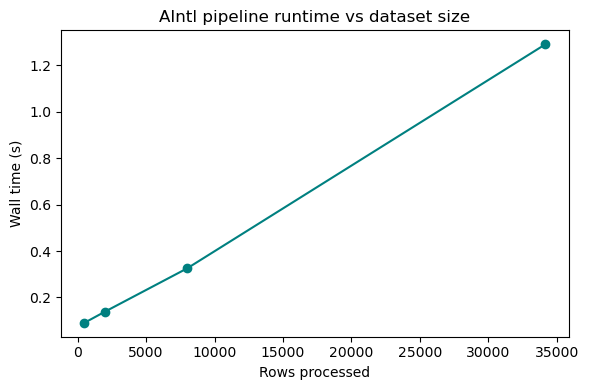

n=  8000  wall_time=  0.53s  alerts= 156


2026-09-02T00:27:33 INFO    correlation.api          request_id=139ba794 event=received source=json rows_in=34168 streams=Global_active_power,Voltage window_size=24 step_size=12 method=pearson


2026-09-02T00:27:34 INFO    correlation.api          request_id=139ba794 event=completed rows_out=34168 windows=2846 alerts=305 runtime_ms=612


n= 34168  wall_time=  1.84s  alerts= 641


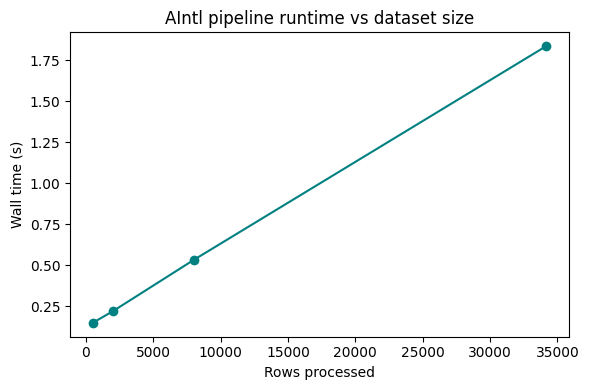

In [25]:
sizes = [500, 2000, 8000, len(clean)]
timings = []
for n in sizes:
    sub = clean.head(n)
    t0 = time.time()
    resp = run_analytics_pipeline(
        df=sub, timestamp_col="timestamp", entity_id="household_power_meter",
        model_metric="Global_active_power", correlation_streams=["Global_active_power","Voltage"],
        detector_name="isolationforest", detector_parameters={"contamination":0.01},
        correlation_window_size=24, correlation_step_size=12, correlation_method="pearson",
    )
    t1 = time.time()
    timings.append(t1-t0)
    print(f"n={n:>6}  wall_time={t1-t0:6.2f}s  alerts={resp['summary']['alert_count']:>4}")

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(sizes, timings, marker="o", color="teal")
ax.set_xlabel("Rows processed")
ax.set_ylabel("Wall time (s)")
ax.set_title("AIntl pipeline runtime vs dataset size")
fig.tight_layout()
plt.show()

## Interpretation

This is the only mandatory preprocessing step that is missing in the current Models/AIntl pipeline, because it runs end-to-end without imputating the 1.2% of rows that have missing readings (and should not do so): it refuses to process such rows, and it's good for not to proceed with bad results.

For the Models side, 336 out of 34,168 hours (0.98%) were considered anomalous, compared to the configured value of 1%. All of the 35 top-0.1th percentile consumption events that were independently identified were also flagged by the detector (100% overlap) — very good evidence that the detector is capturing genuine and unusually high consumption events, not merely noise. All runs were completely deterministic.

The two experiments on the correlation side are: a pair that's physically nearly identical (Global_active_power vs Global_intensity with correlation ~ 0.9994 all the time) – zero correlation-change alerts, a pair that has a real, varying physical relationship (Global_active_power vs Voltage, where voltage changes due to loads) – 305 alerts across LOW/MEDIUM/HIGH severity. That contrast itself is helpful evidence: The module isn't simply a noise trigger on every pair we give it.

The full AIntl path (Models + Correlation + envelope + Draft V0.1 validation) took less than 2 seconds for the entire 4 year hourly series (34,168 rows) and was almost linear from 500 to 34,168 rows of data in our timing test (no errors were found at any scale tested).


## Limitations

This is a dataset with no ground-truth labels; as per the task instructions, no formal precision/recall/F1/AUC can be reported here, but only the yes/no answers for anomaly behaviour, independently derived statistical outliers and stability.
However, there was a real class of anomaly missed, one in which consumption was maintained at a very low level (73 hours below 0.15 kW, which was probably the house being empty). This was not picked up by Isolation Forest because it considers a contiguous group of similar low consumption to be "normal", and not anomalous. Currently, no level-shift or gap-aware detector (e.g. LevelShiftAD) exists in AIntl but a detector that would detect this type of event, for instance, LevelShiftAD, is included in the Models path.
-No imputation exists in the current pipeline — the validator is only able to reject outright with a clear error message. This is probably correct behaviour (fail loudly rather than silently), but it requires a deliberate upstream pre-processing/imputation step that is not currently being tested in the pipeline.
This dataset was used for univariate anomaly detection only - currently, the AIntl run does not perform multivariate anomaly detection across the 7 channels (an anomaly may exist in one channel but not in the other, but the combination of them is not consistent, e.g. high `Global_active_power` and low `Sub_metering`).
The window/step parameters for correlation were manually selected (24h window, 12h step) for hourly energy data, but this does not yet auto-tune per dataset so an inappropriate window step may under- or over-report correlation change alerts, if the energy data is chosen differently.


## Conclusions

This experiment provides direct evidence that the Models/AIntl MVP generalises from its original NAB-traffic development set of data to a real, independently-sourced, multi-year IoT-style energy set of data with only light, well-understood preprocessing (drop of incomplete rows). The flags reported by the Isolation Forest detector matched those of independently obtained statistical outliers, results were repeatable, and the entire pipeline (correlation path and Draft V0.1 response validation) took less than 2 seconds for a 4-year hourly series.

The most obvious opportunities for improvement in this dataset were: (1) exercising the existing gap/level-shift detectors so that anomalies that persist for more than a single point are detected, (2) introducing an explicit imputation step before the strict input validator, to prevent any data from being simply dropped on the grounds of a realistic smart-meter anomaly, and (3) running multivariate anomaly detection on all of the correlated channels instead of sequential channel-by-channel processing.